<a href="https://colab.research.google.com/github/kevanugrah/Portofolio-Kevin-Anugrah/blob/main/Uji%20Kuat%20Tekan%20Beton%2028%20Hari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data = pd.read_excel('/content/PCC 18-19.xlsx')
data

,Tanggal,No Prod,SiO2,Al203,Fe203,CaO,MgO,SO3,FL,LOI,Residu,Blaine,Insol,3,7,28
0,1,1,25.32000,7.73000,3.65000,57.66000,1.02000,1.74000,1.852405,2.725639,6.452902,367.833498,12.171742,223.241592,292.558616,419.469932
1,2,2,25.33000,8.30000,3.63000,58.59000,1.07000,1.70000,2.073865,2.677858,7.148562,384.951085,11.381546,228.848116,292.558616,431.192664
2,3,3,24.41000,7.37000,3.53000,60.21000,1.15000,1.66000,1.480888,2.529241,6.360000,360.088768,9.069093,237.512744,299.184508,437.308872
3,4,4,26.68000,8.16000,3.72000,57.90000,1.12000,1.50000,1.480000,2.520000,8.280128,351.028479,14.170000,216.106016,279.816516,412.844040
4,5,5,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,27,726,21.20232,5.84573,3.13241,58.56837,1.13458,1.72713,0.352800,8.808290,6.340000,429.764962,9.283502,196.228340,276.248728,1912.334368
726,28,727,21.43080,5.87385,3.17214,59.08322,1.07676,1.67198,0.086400,8.328732,6.430000,426.392890,8.699534,179.408768,243.119268,318.042816
727,29,728,21.34252,5.85900,3.16048,59.09016,1.11006,1.78500,0.100800,8.357934,7.290000,424.496209,8.702595,185.015292,252.293580,304.791032
728,30,729,21.40269,5.99123,3.14908,58.63324,1.09012,1.81234,0.194400,8.712950,6.570000,452.805285,9.593691,178.389400,249.745160,334.352704


In [ ]:
data.isnull().sum()

Tanggal    0
No Prod    0
SiO2       0
Al203      0
Fe203      0
CaO        0
MgO        0
SO3        0
FL         0
LOI        0
Residu     0
Blaine     0
Insol      0
3          0
7          0
28         0
dtype: int64

In [ ]:
data.drop('Tanggal', axis=1, inplace=True)

In [ ]:
data

,No Prod,SiO2,Al203,Fe203,CaO,MgO,SO3,FL,LOI,Residu,Blaine,Insol,3,7,28
0,1,25.32000,7.73000,3.65000,57.66000,1.02000,1.74000,1.852405,2.725639,6.452902,367.833498,12.171742,223.241592,292.558616,419.469932
1,2,25.33000,8.30000,3.63000,58.59000,1.07000,1.70000,2.073865,2.677858,7.148562,384.951085,11.381546,228.848116,292.558616,431.192664
2,3,24.41000,7.37000,3.53000,60.21000,1.15000,1.66000,1.480888,2.529241,6.360000,360.088768,9.069093,237.512744,299.184508,437.308872
3,4,26.68000,8.16000,3.72000,57.90000,1.12000,1.50000,1.480000,2.520000,8.280128,351.028479,14.170000,216.106016,279.816516,412.844040
4,5,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,21.20232,5.84573,3.13241,58.56837,1.13458,1.72713,0.352800,8.808290,6.340000,429.764962,9.283502,196.228340,276.248728,1912.334368
726,727,21.43080,5.87385,3.17214,59.08322,1.07676,1.67198,0.086400,8.328732,6.430000,426.392890,8.699534,179.408768,243.119268,318.042816
727,728,21.34252,5.85900,3.16048,59.09016,1.11006,1.78500,0.100800,8.357934,7.290000,424.496209,8.702595,185.015292,252.293580,304.791032
728,729,21.40269,5.99123,3.14908,58.63324,1.09012,1.81234,0.194400,8.712950,6.570000,452.805285,9.593691,178.389400,249.745160,334.352704


In [ ]:
target = data[28]

In [ ]:
target

0       419.469932
1       431.192664
2       437.308872
3       412.844040
4         0.000000
          ...     
725    1912.334368
726     318.042816
727     304.791032
728     334.352704
729     353.211012
Name: 28, Length: 730, dtype: float64

In [ ]:
features = data[['SiO2',	'Al203',	'Fe203',	'CaO',	'MgO',	'SO3',	'FL',	'LOI',	'Residu', 'Blaine',	'Insol'	]]
features

,SiO2,Al203,Fe203,CaO,MgO,SO3,FL,LOI,Residu,Blaine,Insol
0,25.32000,7.73000,3.65000,57.66000,1.02000,1.74000,1.852405,2.725639,6.452902,367.833498,12.171742
1,25.33000,8.30000,3.63000,58.59000,1.07000,1.70000,2.073865,2.677858,7.148562,384.951085,11.381546
2,24.41000,7.37000,3.53000,60.21000,1.15000,1.66000,1.480888,2.529241,6.360000,360.088768,9.069093
3,26.68000,8.16000,3.72000,57.90000,1.12000,1.50000,1.480000,2.520000,8.280128,351.028479,14.170000
4,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
725,21.20232,5.84573,3.13241,58.56837,1.13458,1.72713,0.352800,8.808290,6.340000,429.764962,9.283502
726,21.43080,5.87385,3.17214,59.08322,1.07676,1.67198,0.086400,8.328732,6.430000,426.392890,8.699534
727,21.34252,5.85900,3.16048,59.09016,1.11006,1.78500,0.100800,8.357934,7.290000,424.496209,8.702595
728,21.40269,5.99123,3.14908,58.63324,1.09012,1.81234,0.194400,8.712950,6.570000,452.805285,9.593691


Normalisasi Dataset

In [ ]:
scaler_X = MinMaxScaler()

# Fit dan transform MinMaxScaler pada X dan y
x = scaler_X.fit_transform(features)

In [ ]:
original_data = pd.DataFrame(features, columns=['SiO2',	'Al203',	'Fe203',	'CaO',	'MgO',	'SO3',	'FL',	'LOI',	'Residu', 'Blaine',	'Insol'	])
scaled_data = pd.DataFrame(x, columns=['SiO2',	'Al203',	'Fe203',	'CaO',	'MgO',	'SO3',	'FL',	'LOI',	'Residu', 'Blaine',	'Insol'	])

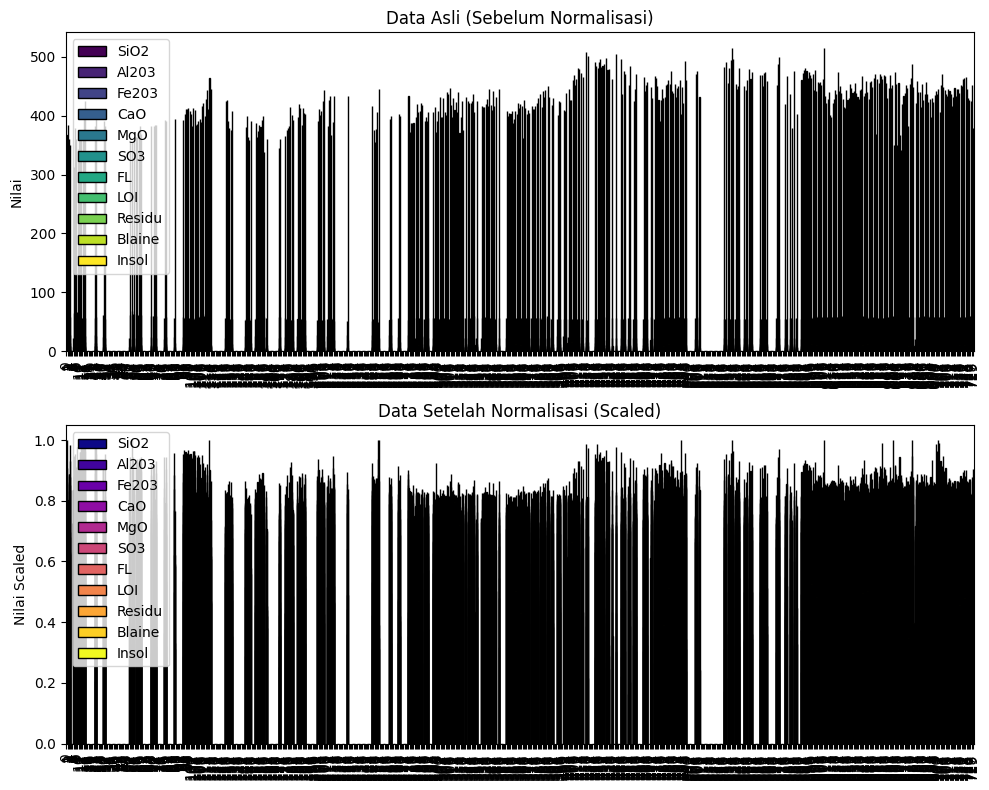

In [ ]:
# Plot perbedaan sebelum dan sesudah normalisasi menggunakan grafik bar
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot untuk data asli (sebelum normalisasi)
original_data.plot(kind='bar', ax=axs[0], colormap='viridis', edgecolor='back')
axs[0].set_title('Data Asli (Sebelum Normalisasi)')
axs[0].set_ylabel('Nilai')

# Plot untuk data setelah normalisasi
scaled_data.plot(kind='bar', ax=axs[1], colormap='plasma', edgecolor='black')
axs[1].set_title('Data Setelah Normalisasi (Scaled)')
axs[1].set_ylabel('Nilai Scaled')

plt.tight_layout()
plt.show()

split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, target, test_size=0.2, random_state=42)

regresi linier

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inisialisasi model
linear_model = LinearRegression()

# Latih model
linear_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_test_pred_linear = linear_model.predict(X_test)

# Evaluasi model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Model: Linear Regression")
print(f"Mean Squared Error: {mse_linear}")
print(f"R-squared: {r2_linear}")


Model: Linear Regression
Mean Squared Error: 17598.912715809845
R-squared: 0.6331170775311717


In [ ]:
# Prediksi nilai target pada data latih dan data uji
accuracy = linear_model.predict(X_train)

In [ ]:
plt.plot()
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation test'], loc='upper left')
plt.show()

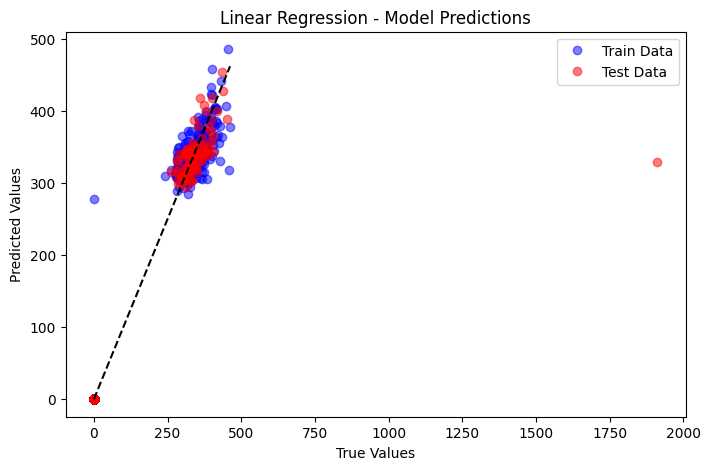

In [ ]:
# Plot grafik prediksi untuk melihat overfitting atau underfitting
plt.figure(figsize=(8, 5))
plt.plot(y_train, y_train_pred_linear, 'o', label='Train Data', color='blue', alpha=0.5)
plt.plot(y_test, y_test_pred_linear, 'o', label='Test Data', color='red', alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='black', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title("Linear Regression - Model Predictions")
plt.legend()
plt.show()


ridge

In [ ]:
from sklearn.linear_model import Ridge

# Inisialisasi model
ridge_model = Ridge(alpha=1.0)

# Latih model
ridge_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_ridge = ridge_model.predict(X_test)

# Evaluasi model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nModel: Ridge Regression")
print(f"Mean Squared Error: {mse_ridge}")
print(f"R-squared: {r2_ridge}")



Model: Ridge Regression
Mean Squared Error: 17607.158207057335
R-squared: 0.6329451845298869


In [ ]:
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

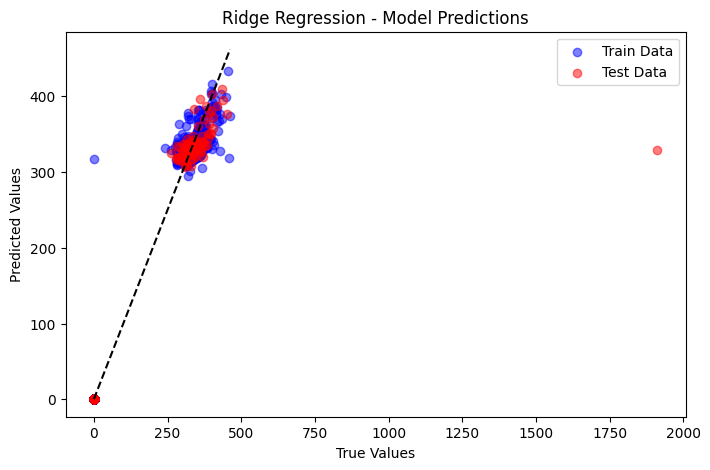

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_train_pred_ridge, label='Train Data', color='blue', alpha=0.5)
plt.scatter(y_test, y_test_pred_ridge, label='Test Data', color='red', alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='black', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title("Ridge Regression - Model Predictions")
plt.legend()
plt.show()


lasso

In [ ]:
from sklearn.linear_model import Lasso

# Inisialisasi model
lasso_model = Lasso(alpha=1.0)

# Latih model
lasso_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_lasso = lasso_model.predict(X_test)

# Evaluasi model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nModel: Lasso Regression")
print(f"Mean Squared Error: {mse_lasso}")
print(f"R-squared: {r2_lasso}")



Model: Lasso Regression
Mean Squared Error: 17570.253705834246
R-squared: 0.6337145292888287


In [ ]:
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

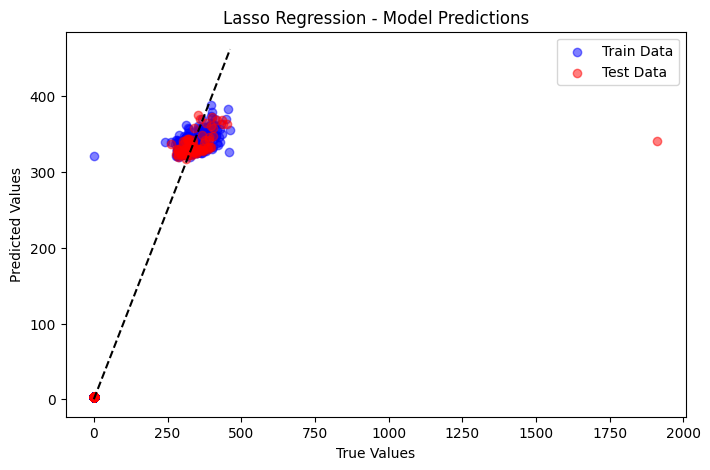

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_train_pred_lasso, label='Train Data', color='blue', alpha=0.5)
plt.scatter(y_test, y_test_pred_lasso, label='Test Data', color='red', alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='black', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title("Lasso Regression - Model Predictions")
plt.legend()
plt.show()

svr

In [ ]:
from sklearn.svm import SVR

# Inisialisasi model
svr_model = SVR(kernel='linear')

# Latih model
svr_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_svr = svr_model.predict(X_test)

# Evaluasi model
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nModel: SVR")
print(f"Mean Squared Error: {mse_svr}")
print(f"R-squared: {r2_svr}")



Model: SVR
Mean Squared Error: 18451.25230806806
R-squared: 0.6153484320703266


In [ ]:
y_train_pred_svr = svr_model.predict(X_train)
y_test_pred_svr = svr_model.predict(X_test)

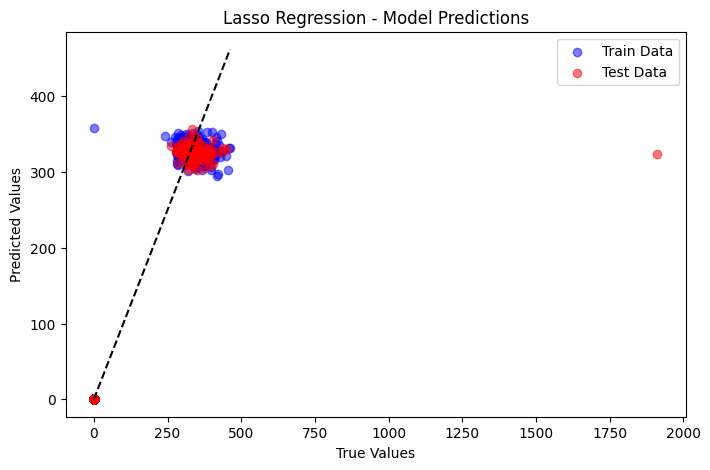

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_train_pred_svr, label='Train Data', color='blue', alpha=0.5)
plt.scatter(y_test, y_test_pred_svr, label='Test Data', color='red', alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='black', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title("SVR Regression - Model Predictions")
plt.legend()
plt.show()

decission tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Inisialisasi model
dt_model = DecisionTreeRegressor()

# Latih model
dt_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_dt = dt_model.predict(X_test)

# Evaluasi model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nModel: Decision Tree Regressor")
print(f"Mean Squared Error: {mse_dt}")
print(f"R-squared: {r2_dt}")



Model: Decision Tree Regressor
Mean Squared Error: 17654.179424338457
R-squared: 0.6319649375173176


rf

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi model
rf_model = RandomForestRegressor()

# Latih model
rf_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nModel: Random Forest Regressor")
print(f"Mean Squared Error: {mse_rf}")
print(f"R-squared: {r2_rf}")



Model: Random Forest Regressor
Mean Squared Error: 17461.822929123053
R-squared: 0.6359749757657085


gradient boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Inisialisasi model
gb_model = GradientBoostingRegressor()

# Latih model
gb_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_gb = gb_model.predict(X_test)

# Evaluasi model
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("\nModel: Gradient Boosting Regressor")
print(f"Mean Squared Error: {mse_gb}")
print(f"R-squared: {r2_gb}")



Model: Gradient Boosting Regressor
Mean Squared Error: 17630.34987923452
R-squared: 0.6324617098628604


neural network regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

# Inisialisasi model
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000)

# Latih model
nn_model.fit(X_train, y_train)

# Prediksi nilai target pada data uji
y_pred_nn = nn_model.predict(X_test)

# Evaluasi model
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("\nModel: Neural Network Regressor")
print(f"Mean Squared Error: {mse_nn}")
print(f"R-squared: {r2_nn}")


Model: Neural Network Regressor
Mean Squared Error: 17523.62257594569
R-squared: 0.6346866441852317



Model: Linear Regression
Mean Squared Error: 17598.912715809845
R-squared: 0.6331170775311717


Model: Ridge Regression
Mean Squared Error: 17607.158207057335
R-squared: 0.6329451845298869

Model: Lasso Regression
Mean Squared Error: 17570.253705834246
R-squared: 0.6337145292888287

Model: SVR
Mean Squared Error: 18451.25230806806
R-squared: 0.6153484320703266


Model: Decision Tree Regressor
Mean Squared Error: 17654.179424338457
R-squared: 0.6319649375173176

Model: Random Forest Regressor
Mean Squared Error: 17461.822929123053
R-squared: 0.6359749757657085


Model: Gradient Boosting Regressor
Mean Squared Error: 17630.34987923452
R-squared: 0.6324617098628604

Model: Neural Network Regressor
Mean Squared Error: 17523.62257594569
R-squared: 0.6346866441852317

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Model: Linear Regression
Train MSE: 594.6076773795397, Train R-squared: 0.9785549590004587
Test MSE: 17598.912715809845, Test R-squared: 0.6331170775311717


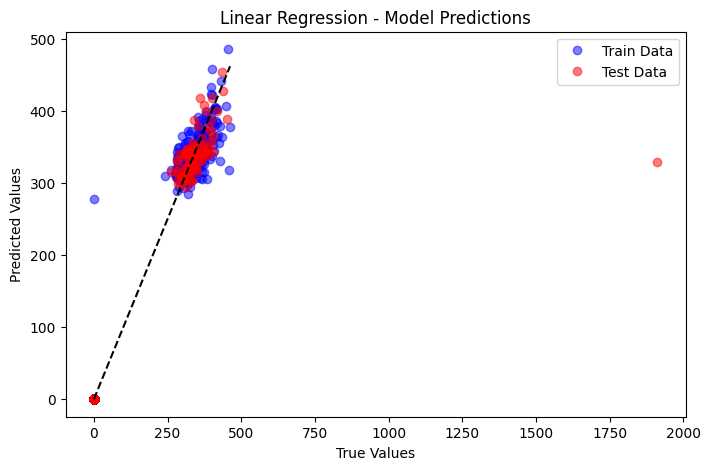


Model: Ridge Regression
Train MSE: 677.8974393447387, Train R-squared: 0.9755510415803921
Test MSE: 17607.158207057335, Test R-squared: 0.6329451845298869


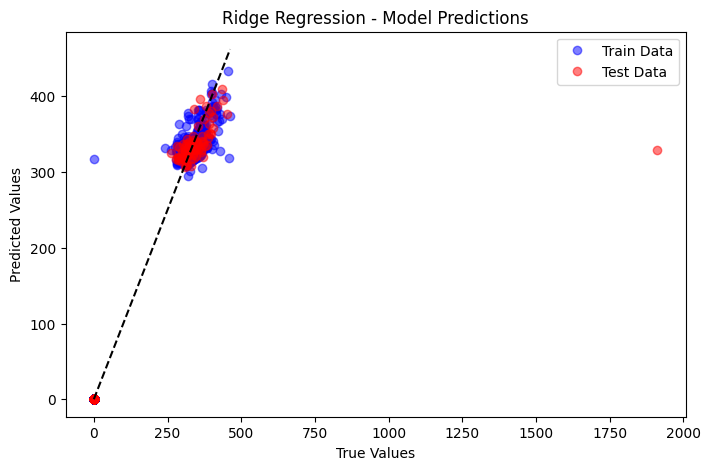


Model: Lasso Regression
Train MSE: 842.4545357908768, Train R-squared: 0.9696161473395288
Test MSE: 17570.253705834246, Test R-squared: 0.6337145292888287


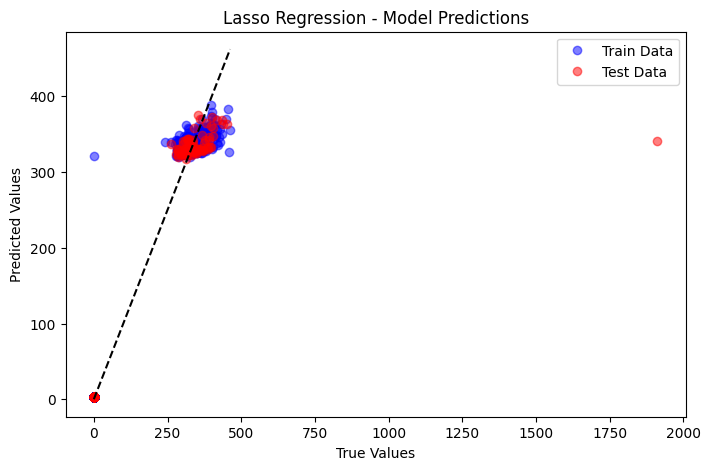


Model: SVR
Train MSE: 1488.3994492166212, Train R-squared: 0.9463195844479968
Test MSE: 19123.990165774154, Test R-squared: 0.6013239275298328


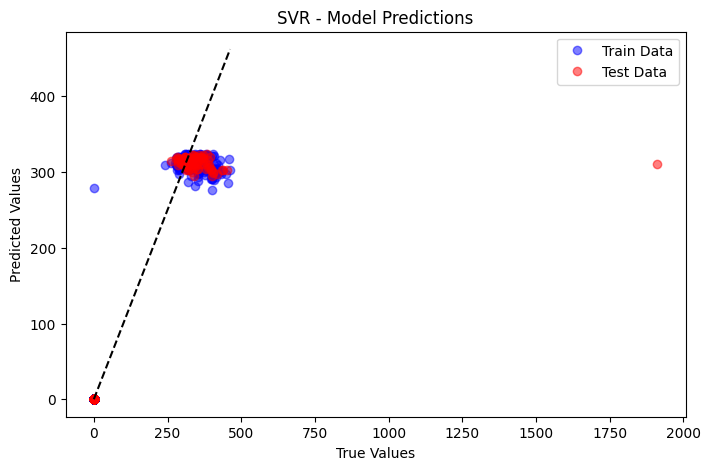


Model: Decision Tree Regressor
Train MSE: 5.532832650317233e-30, Train R-squared: 1.0
Test MSE: 17810.188436241024, Test R-squared: 0.6287126319264802


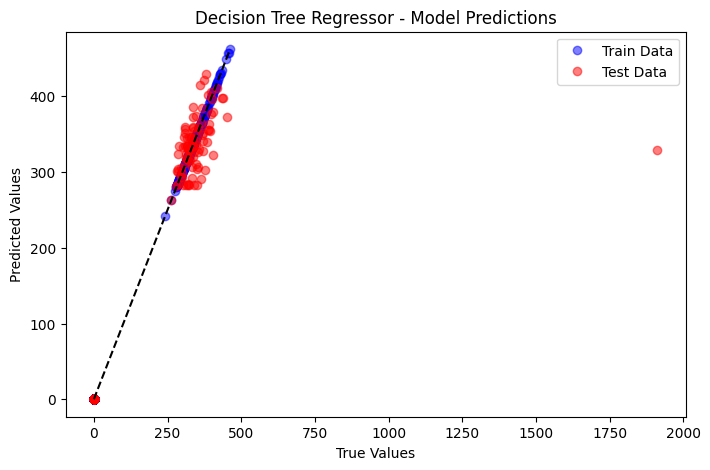


Model: Random Forest Regressor
Train MSE: 98.85552020929948, Train R-squared: 0.9964346900240808
Test MSE: 17587.92848503585, Test R-squared: 0.6333460647846749


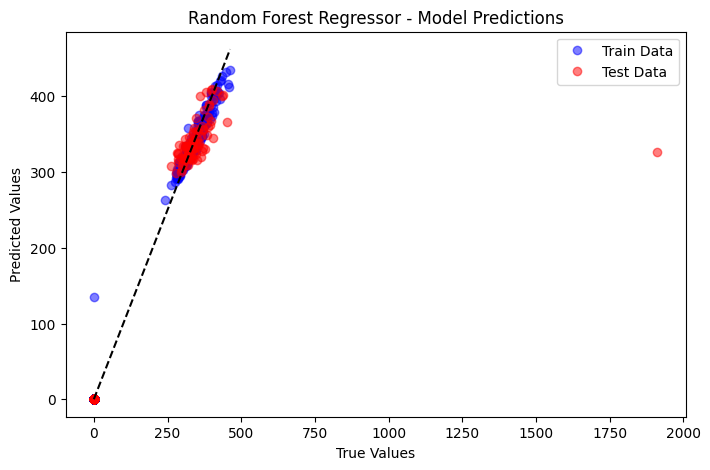


Model: Gradient Boosting Regressor
Train MSE: 138.10197092412955, Train R-squared: 0.9950192327794398
Test MSE: 17626.240137698624, Test R-squared: 0.6325473852684738


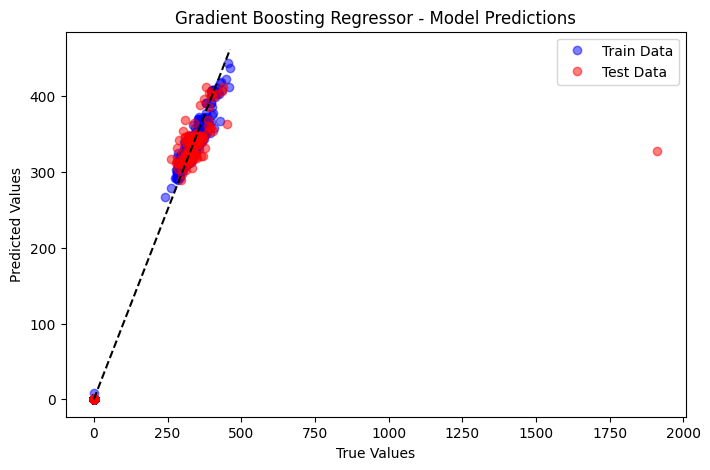


Model: Neural Network Regressor (MLP Regressor)
Train MSE: 6644.159164478802, Train R-squared: 0.7603726438285158
Test MSE: 25965.461963184094, Test R-squared: 0.458700391203809


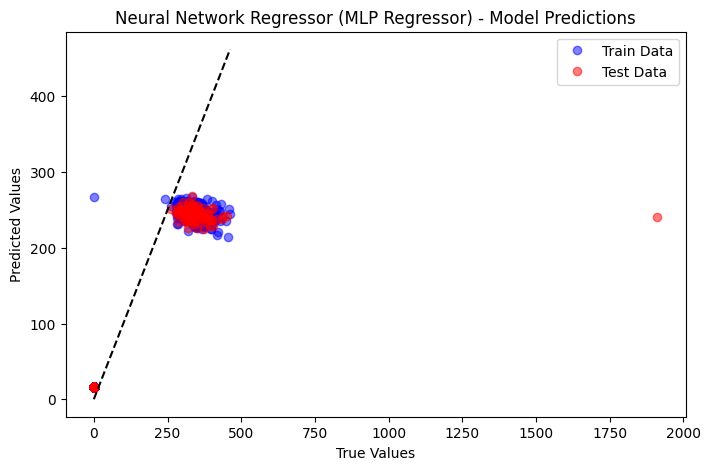

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Fungsi untuk membuat grafik line plot dari prediksi model
def plot_model_predictions(model_name, y_train_pred, y_test_pred):
    plt.figure(figsize=(8, 5))
    plt.plot(y_train, y_train_pred, 'o', label='Train Data', color='blue', alpha=0.5)
    plt.plot(y_test, y_test_pred, 'o', label='Test Data', color='red', alpha=0.5)
    plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='black', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(f"{model_name} - Model Predictions")
    plt.legend()
    plt.show()

# Fungsi untuk melatih dan mengevaluasi model
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    return mse_train, r2_train, mse_test, r2_test, y_train_pred, y_test_pred

# List untuk menyimpan hasil evaluasi dari setiap model
models_evaluation = []

# Model: Linear Regression
linear_model = LinearRegression()
mse_train_linear, r2_train_linear, mse_test_linear, r2_test_linear, y_train_pred_linear, y_test_pred_linear = train_and_evaluate_model(linear_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Linear Regression", mse_train_linear, r2_train_linear, mse_test_linear, r2_test_linear))

# Model: Ridge Regression
ridge_model = Ridge(alpha=1.0)
mse_train_ridge, r2_train_ridge, mse_test_ridge, r2_test_ridge, y_train_pred_ridge, y_test_pred_ridge = train_and_evaluate_model(ridge_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Ridge Regression", mse_train_ridge, r2_train_ridge, mse_test_ridge, r2_test_ridge))

# Model: Lasso Regression
lasso_model = Lasso(alpha=1.0)
mse_train_lasso, r2_train_lasso, mse_test_lasso, r2_test_lasso, y_train_pred_lasso, y_test_pred_lasso = train_and_evaluate_model(lasso_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Lasso Regression", mse_train_lasso, r2_train_lasso, mse_test_lasso, r2_test_lasso))

# Model: SVR
svr_model = SVR()
mse_train_svr, r2_train_svr, mse_test_svr, r2_test_svr, y_train_pred_svr, y_test_pred_svr = train_and_evaluate_model(svr_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("SVR", mse_train_svr, r2_train_svr, mse_test_svr, r2_test_svr))

# Model: Decision Tree Regressor
dt_model = DecisionTreeRegressor()
mse_train_dt, r2_train_dt, mse_test_dt, r2_test_dt, y_train_pred_dt, y_test_pred_dt = train_and_evaluate_model(dt_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Decision Tree Regressor", mse_train_dt, r2_train_dt, mse_test_dt, r2_test_dt))

# Model: Random Forest Regressor
rf_model = RandomForestRegressor()
mse_train_rf, r2_train_rf, mse_test_rf, r2_test_rf, y_train_pred_rf, y_test_pred_rf = train_and_evaluate_model(rf_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Random Forest Regressor", mse_train_rf, r2_train_rf, mse_test_rf, r2_test_rf))

# Model: Gradient Boosting Regressor
gb_model = GradientBoostingRegressor()
mse_train_gb, r2_train_gb, mse_test_gb, r2_test_gb, y_train_pred_gb, y_test_pred_gb = train_and_evaluate_model(gb_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Gradient Boosting Regressor", mse_train_gb, r2_train_gb, mse_test_gb, r2_test_gb))

# Model: Neural Network Regressor (MLP Regressor)
nn_model = MLPRegressor()
mse_train_nn, r2_train_nn, mse_test_nn, r2_test_nn, y_train_pred_nn, y_test_pred_nn = train_and_evaluate_model(nn_model, X_train, X_test, y_train, y_test)
models_evaluation.append(("Neural Network Regressor (MLP Regressor)", mse_train_nn, r2_train_nn, mse_test_nn, r2_test_nn))

# Menampilkan grafik untuk setiap model
for model_name, mse_train, r2_train, mse_test, r2_test in models_evaluation:
    print(f"\nModel: {model_name}")
    print(f"Train MSE: {mse_train}, Train R-squared: {r2_train}")
    print(f"Test MSE: {mse_test}, Test R-squared: {r2_test}")

    # Plot grafik prediksi untuk melihat overfitting atau underfitting
    if model_name == "Linear Regression":
        plot_model_predictions(model_name, y_train_pred_linear, y_test_pred_linear)
    elif model_name == "Ridge Regression":
        plot_model_predictions(model_name, y_train_pred_ridge, y_test_pred_ridge)
    elif model_name == "Lasso Regression":
        plot_model_predictions(model_name, y_train_pred_lasso, y_test_pred_lasso)
    elif model_name == "SVR":
        plot_model_predictions(model_name, y_train_pred_svr, y_test_pred_svr)
    elif model_name == "Decision Tree Regressor":
        plot_model_predictions(model_name, y_train_pred_dt, y_test_pred_dt)
    elif model_name == "Random Forest Regressor":
        plot_model_predictions(model_name, y_train_pred_rf, y_test_pred_rf)
    elif model_name == "Gradient Boosting Regressor":
        plot_model_predictions(model_name, y_train_pred_gb, y_test_pred_gb)
    elif model_name == "Neural Network Regressor (MLP Regressor)":
        plot_model_predictions(model_name, y_train_pred_nn, y_test_pred_nn)
